In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [3]:
mkt_cap_df          = pd.read_csv('../../00_input/KOSPI_KOSDAQ_mkt_cap.csv', index_col='Date', parse_dates=True)
sales_df            = pd.read_csv('../../00_input/KOSPI_KOSDAQ_sales.csv', index_col='Date', parse_dates=True)
adj_close_df        = pd.read_csv('../../00_input/KOSPI_KOSDAQ_adj_close.csv', index_col='Date', parse_dates=True)
factors             = pd.read_csv('../../00_input/Factors.csv', index_col='Date', parse_dates=True)
total_adj_close_df  = pd.read_csv('../../00_input/KOSPI_KOSDAQ_total_adj_close.csv', index_col='Date', parse_dates=True)
trading_value_60    = pd.read_csv('../../00_input/KOSPI_KOSDAQ_trading_value_60.csv', index_col='Date', parse_dates=True)
trading_value       = pd.read_csv('../../00_input/KOSPI_KOSDAQ_trading_value.csv', index_col='Date', parse_dates=True)

In [18]:
# 전처리 함수 정의
def make_ff_factors(factors, annual_rf=True):
    """
    factors: DataFrame with columns ['KOSPI','SMB','HML','MOM','RF']
    """
    
    df = factors.copy()

    # 0. resampling
    df = df.resample('ME').last()
    
    # 1. 지수 → 수익률 변환
    ret_cols = ['KOSPI','SMB','HML','MOM']
    df[ret_cols] = df[ret_cols].pct_change()
    
    # 2. 무위험금리 변환 (연율 → 일/월 수익률)
    df['RF'] = df['RF'] / 100  # % → 소수화 (예: 3.5% → 0.035)
    df['RF'] = (1 + df['RF']) ** (1/12) - 1
    
    # 4. 컬럼 정리
    df = df[['KOSPI','SMB','HML','MOM','RF']].dropna()
    
    return df

In [19]:
factors_monthly = make_ff_factors(factors)[:-1]

In [3]:
sales_df        = sales_df.shift(14)

In [4]:
# 기간 설정: 2001-01-31 ~ 2024-12-31 월말
start_date = '2015-01-31'
end_date   = '2026-02-28'
idx = mkt_cap_df.loc[start_date:end_date].index

sales_per_mkt_cap = sales_df.div(mkt_cap_df, axis=0)

In [ ]:
# 수익률 계산용: 수정주가 로드 후 월 수익률·월말 리스트 생성
price_m = adj_close_df.resample('ME').last()
ret_m = price_m.pct_change(fill_method=None)
month_ends = price_m.loc['2015-01-31':'2026-02-28'].index.tolist()

In [6]:
sales_m = sales_per_mkt_cap.resample('ME').last()

In [32]:
# 월간 리밸런싱: Sales/시총, 각각 상위 20종목 → 월 수익률
portfolio_sales = pd.Series(dtype=float)

def select_top20(fac_series, n=20):
    f_t = fac_series.dropna()
    n_sel = min(n, len(f_t))
    return f_t.nlargest(n_sel).index.tolist() if n_sel else []

for i in range(len(month_ends) - 1):
    rebal_start = month_ends[i]
    rebal_end   = month_ends[i + 1]

    if rebal_start not in sales_m.index:
        continue

    sel_sales = select_top20(sales_m.loc[rebal_start])
    
    r = ret_m.loc[rebal_end, ret_m.columns.intersection(sel_sales)].dropna()
    portfolio_sales.loc[rebal_end] = r.mean() if not r.empty else np.nan

# 공통 월말 인덱스로 맞춰 그래프 끊김 방지
common_idx = pd.date_range(start=month_ends[0], end=month_ends[-1], freq='ME')
portfolio_sales = portfolio_sales.reindex(common_idx, fill_value=0)
# pd.DataFrame({'cf': portfolio_cf, 'sales': portfolio_sales, 'earnings': portfolio_earnings})

In [33]:
# 월 수익률 → NAV (월간 리밸런싱)
nav = (1 + portfolio_sales).cumprod()
pd.DataFrame({'sales': nav})

,sales
2015-01-31,1.000000
2015-02-28,1.164697
2015-03-31,1.185298
2015-04-30,1.267897
2015-05-31,1.197645
...,...
2025-10-31,6.773201
2025-11-30,6.823138
2025-12-31,7.110446
2026-01-31,7.316986


<Axes: >

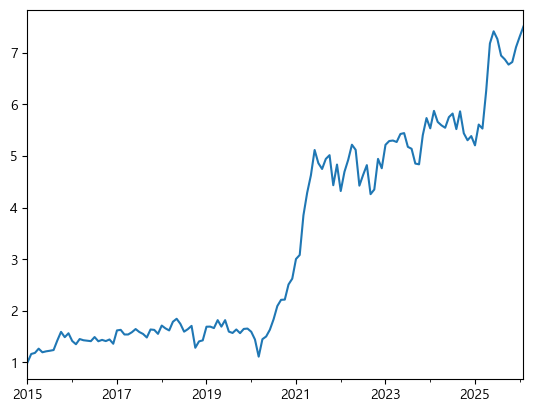

In [34]:
nav.plot()

In [24]:
# 코스피 지수 데이터 불러오기
ks_df = pd.read_csv('../../00_input/KOSPI_index.csv', index_col='Date', parse_dates=True)

<Axes: >

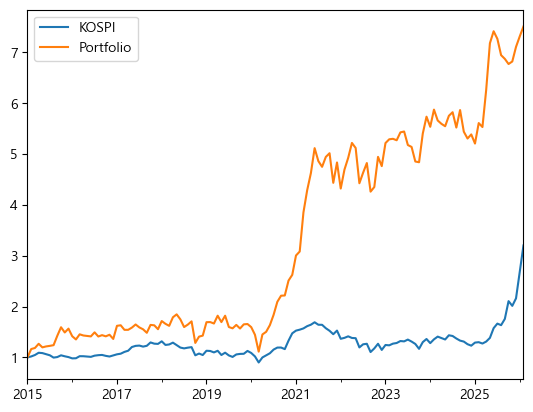

In [ ]:
# 1) 월말 데이터로 리샘플링
ks_monthly = ks_df.resample('ME').last()

# 2) 포트폴리오 데이터와 Index 맞추기
ks_monthly = ks_monthly.loc[nav.index]

# 3) 포트폴리오 NAV와 초기값 통일
ks_monthly = (ks_monthly / ks_monthly.iloc[0]) * nav.iloc[0]

# 4) 코스피200와 포트폴리오 데이터 병합
ks_monthly['Portfolio'] = nav

# 5) 포트폴리오 NAV와 코스피200 시각화
ks_monthly.plot()

In [28]:
# 무위험 수익률 (연 2%)
rf_annual = 0.02
rf_monthly = (1 + rf_annual) ** (1/12) - 1

# 수익률 시리즈 (월별, NaN 제외)
returns = portfolio_sales.dropna()

# 1) CAGR
start_val = 1.0
end_val = nav.iloc[-1] / nav.iloc[0]   # 이미 초기값 1이면 nav.iloc[-1]만 써도 됨
years = (nav.index[-1] - nav.index[0]).days / 365.25
cagr = (end_val ** (1 / years)) - 1 if years > 0 else 0

# 2) 연환산 변동성 (월 수익률 × sqrt(12))
volatility = returns.std() * np.sqrt(12)

# 3) Sharpe Ratio (연환산 기준, 무위험 2%)
monthly_excess = returns.mean() - rf_monthly
monthly_vol = returns.std()
monthly_sharpe = (monthly_excess / monthly_vol) if monthly_vol > 0 else np.nan
sharpe_ratio = monthly_sharpe * np.sqrt(12) if monthly_vol > 0 else np.nan

# 4) MDD (Maximum Drawdown)
# 누적 최고점 대비 현재 NAV가 얼마나 떨어졌는지
cummax = nav.cummax()
drawdown = (nav - cummax) / cummax   # 구간별 drawdown (0 ~ -1 사이)
mdd = drawdown.min()                 # MDD = drawdown의 최솟값 (음수)

# CAGR 계산
print(f"CAGR: {cagr:.2%}")
# 연 환산 변동성 계산
print(f"Annualized Volatility: {volatility:.2%}")
# Sharpe Ratio 계산
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
# MDD 출력 (예: -15.3% 형태로)
print(f"Maximum Drawdown: {mdd:.2%}")


CAGR: 19.97%
Annualized Volatility: 27.75%
Sharpe Ratio: 0.72
Maximum Drawdown: -39.74%


In [21]:
import statsmodels.api as sm

# 팩터 데이터 불러오기
factors = factors_monthly

# 포트폴리오 수익률을 DataFrame으로 변환
portfolio_df = portfolio_sales.to_frame(name='Return')

# 1. 두 데이터 공통 구간 맞추기
df = pd.concat([portfolio_df, factors], axis=1, join="inner").dropna()

In [22]:
# 2. 종속변수: 포트폴리오 초과수익률
y = df['Return'] - df['RF']

# 3. 독립변수: MKT, SMB, HML, MOM
X = pd.DataFrame({
    "MKT": df['KOSPI'] - df['RF'],
    "SMB": df['SMB'],
    "HML": df['HML'],
    "MOM": df['MOM']
}, index=df.index)

X = sm.add_constant(X, has_constant='add')

# 4. OLS 회귀
model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":12})  # Newey-West 표준오차
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.620
Model:                            OLS   Adj. R-squared:                  0.609
Method:                 Least Squares   F-statistic:                     46.11
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           5.28e-24
Time:                        03:40:42   Log-Likelihood:                 213.38
No. Observations:                 134   AIC:                            -416.8
Df Residuals:                     129   BIC:                            -402.3
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0087      0.004      2.390      0.0

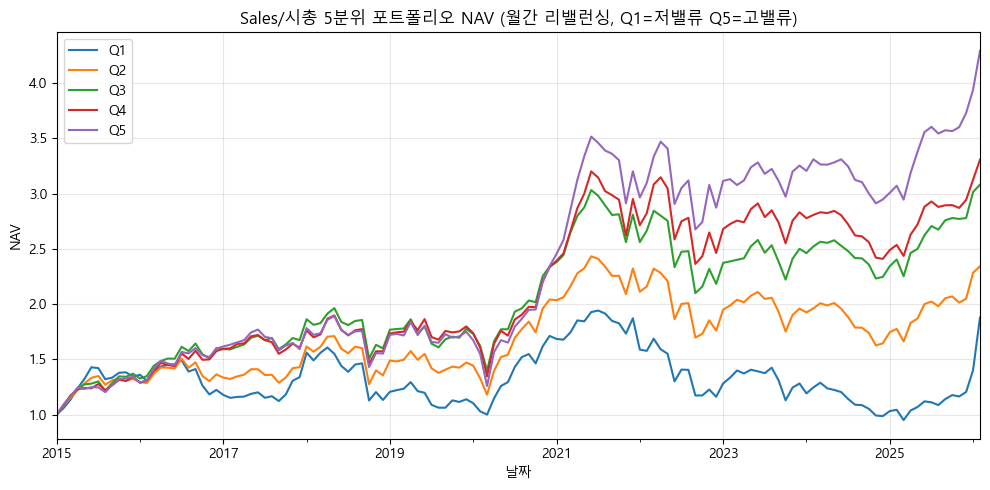

In [15]:
# sales_m 기준 월말 5분위 포트폴리오 (Q1=저밸류, Q5=고밸류)
portfolio_sales_q = {k: pd.Series(dtype=float) for k in range(1, 6)}

for i in range(len(month_ends) - 1):
    rebal_start = month_ends[i]
    rebal_end   = month_ends[i + 1]
    if rebal_start not in sales_m.index or rebal_end not in ret_m.index:
        continue
    s = sales_m.loc[rebal_start].dropna()
    if len(s) < 5:
        continue
    rk = s.rank(method='first')
    q_labels = pd.cut(rk, bins=5, labels=[1, 2, 3, 4, 5])
    for q in range(1, 6):
        tickers = q_labels[q_labels == q].index.tolist()
        r = ret_m.loc[rebal_end, ret_m.columns.intersection(tickers)].dropna()
        portfolio_sales_q[q].loc[rebal_end] = r.mean() if not r.empty else np.nan

common_idx = pd.date_range(start=month_ends[0], end=month_ends[-1], freq='ME')
for q in range(1, 6):
    portfolio_sales_q[q] = portfolio_sales_q[q].reindex(common_idx, fill_value=0)

nav_sales_q = {q: (1 + portfolio_sales_q[q]).cumprod() for q in range(1, 6)}
nav_sales_q_df = pd.DataFrame({f'Q{q}': nav_sales_q[q] for q in range(1, 6)})

nav_sales_q_df.plot(figsize=(10, 5), title='Sales/시총 5분위 포트폴리오 NAV (월간 리밸런싱, Q1=저밸류 Q5=고밸류)')
plt.xlabel('날짜')
plt.ylabel('NAV')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
def summarize_portfolio_performance(returns: pd.Series, rf_annual: float = 0.02) -> pd.Series:
    returns = returns.dropna()
    if returns.empty:
        return pd.Series(
            {
                'CAGR': np.nan,
                'Annualized Volatility': np.nan,
                'Sharpe Ratio': np.nan,
                'Maximum Drawdown': np.nan,
            }
        )

    nav = (1 + returns).cumprod()
    rf_monthly = (1 + rf_annual) ** (1 / 12) - 1
    years = (nav.index[-1] - nav.index[0]).days / 365.25
    cagr = (nav.iloc[-1] / nav.iloc[0]) ** (1 / years) - 1 if years > 0 else np.nan
    volatility = returns.std() * np.sqrt(12)
    monthly_vol = returns.std()
    monthly_sharpe = (returns.mean() - rf_monthly) / monthly_vol if monthly_vol > 0 else np.nan
    sharpe_ratio = monthly_sharpe * np.sqrt(12) if monthly_vol > 0 else np.nan
    drawdown = nav / nav.cummax() - 1
    mdd = drawdown.min()

    return pd.Series(
        {
            'CAGR': cagr,
            'Annualized Volatility': volatility,
            'Sharpe Ratio': sharpe_ratio,
            'Maximum Drawdown': mdd,
        }
    )

quantile_perf = pd.DataFrame(
    {
        f'Q{q}': summarize_portfolio_performance(portfolio_sales_q[q])
        for q in range(1, 6)
    }
).T

display(
    quantile_perf.style.format(
        {
            'CAGR': '{:.2%}',
            'Annualized Volatility': '{:.2%}',
            'Sharpe Ratio': '{:.2f}',
            'Maximum Drawdown': '{:.2%}',
        }
    )
)


,CAGR,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
Q1,5.86%,23.92%,0.27,-51.03%
Q2,7.99%,20.04%,0.38,-33.16%
Q3,10.69%,19.08%,0.52,-30.75%
Q4,11.40%,19.78%,0.54,-29.06%
Q5,14.06%,20.53%,0.64,-33.44%
